# Resolution Broadening Validation

This notebook validates NEREIDS' instrument resolution broadening model against
known analytical properties and explores the effect of VENUS-like beamline
parameters on measured transmission spectra.

## Physics Background

At a time-of-flight (TOF) neutron beamline, the measured spectrum is a convolution
of the true spectrum with the instrument resolution function:

$$T_{\text{meas}}(E) = \int T_{\text{true}}(E') \, R(E, E') \, dE'$$

The resolution function $R(E, E')$ arises from:
- **Timing uncertainty** $\Delta t$: moderator pulse width, detector timing jitter
- **Path length uncertainty** $\Delta L$: sample thickness, beam divergence

For a TOF beamline with flight path $L$ and uncertainties $\Delta t$, $\Delta L$:

$$\left(\frac{\Delta E}{E}\right)^2 = \left(\frac{2\Delta t}{t}\right)^2 + \left(\frac{2\Delta L}{L}\right)^2$$

NEREIDS implements this as a Gaussian convolution in energy space.

**SAMMY reference**: `rsl/mrsl*.f90`, `grp/mgrp4.f90` (4-point Lagrange quadrature).

## Prerequisites

```bash
pixi run build
```

**Previous:** [Doppler Broadening](03_doppler_broadening.ipynb)

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## 1. Setup: U-238 Test Case

We use the familiar U-238 first resonance with Doppler broadening at 300 K
as the baseline, then apply resolution broadening on top.

In [2]:
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Fine grid
E_low  = np.geomspace(0.5, 6.174, 200)
E_core = np.linspace(6.174, 7.174, 2000)
E_high = np.geomspace(7.174, 30.0, 200)
energies = np.sort(np.unique(np.concatenate([E_low, E_core, E_high])))

# Unbroadened cross-sections
xs = nereids.cross_sections(energies, u238)

# Doppler-broadened at 300 K
sigma_300 = np.asarray(nereids.doppler_broaden(
    energies, xs['total'], awr=236.006, temperature_k=300.0
))

thickness = 5e-4  # atoms/barn
print(f"Grid: {len(energies)} points")
print(f"Doppler-broadened peak total: {sigma_300.max():.0f} barns")

Grid: 2398 points
Doppler-broadened peak total: 7599 barns


## 2. Gaussian Resolution: Direct API

`nereids.resolution_broaden()` applies Gaussian resolution broadening to any
cross-section or spectrum array. Parameters:
- `flight_path_m`: flight path in meters
- `delta_t_us`: timing uncertainty in microseconds
- `delta_l_m`: path length uncertainty in meters

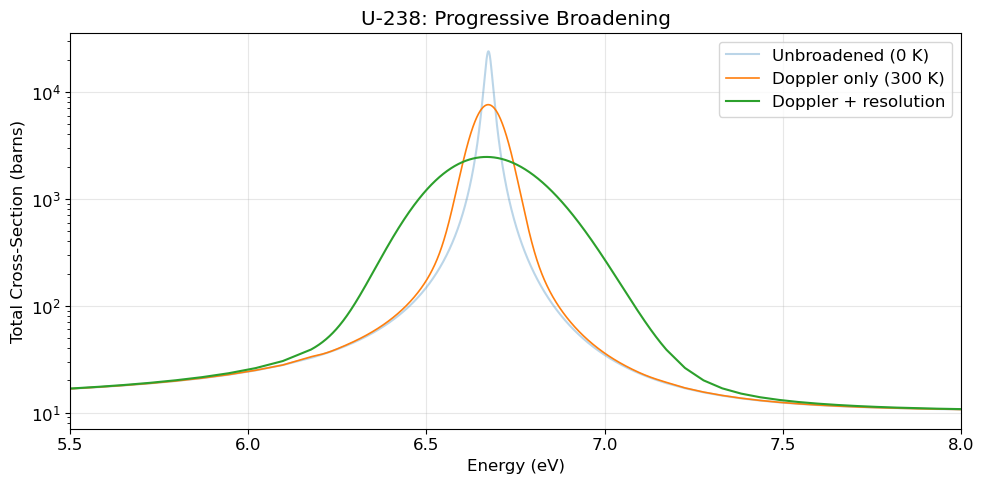

Peak total (unbroadened):       23990 barns
Peak total (Doppler 300 K):     7599 barns
Peak total (Doppler + resol.):  2464 barns


In [3]:
# VENUS-like parameters
flight_path = 25.0   # meters
delta_t = 10.0       # microseconds
delta_l = 0.01       # meters

# Broaden the Doppler-broadened total cross-section
sigma_resolved = np.asarray(nereids.resolution_broaden(
    energies, sigma_300,
    flight_path_m=flight_path, delta_t_us=delta_t, delta_l_m=delta_l
))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(energies, xs['total'], alpha=0.3, label='Unbroadened (0 K)')
ax.semilogy(energies, sigma_300, label='Doppler only (300 K)', linewidth=1.2)
ax.semilogy(energies, sigma_resolved, label='Doppler + resolution', linewidth=1.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Total Cross-Section (barns)')
ax.set_title('U-238: Progressive Broadening')
ax.legend()
ax.set_xlim(5.5, 8.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak total (unbroadened):       {xs['total'].max():.0f} barns")
print(f"Peak total (Doppler 300 K):     {sigma_300.max():.0f} barns")
print(f"Peak total (Doppler + resol.):  {sigma_resolved.max():.0f} barns")

## 3. Energy-Dependent Resolution Width

The Gaussian resolution width $\Delta E$ is energy-dependent:

$$\Delta E = E \sqrt{\left(\frac{2\Delta t}{t}\right)^2 + \left(\frac{2\Delta L}{L}\right)^2}$$

where $t = L / v$ is the TOF. Since $E \propto 1/t^2$, at higher energies the
resolution is coarser (broader kernel).

In [4]:
# Compute dE/E at each energy
# t = L / v, v = sqrt(2E/m_n), E in eV
# Using nereids TOF conversion for consistency
E_sample = np.array([0.5, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0])
print(f"{'E (eV)':>10} {'TOF (us)':>10} {'dE/E (%)':>10} {'dE (meV)':>12}")
print("-" * 46)
for E in E_sample:
    tof = nereids.energy_to_tof(E, flight_path)
    dE_over_E = np.sqrt((2*delta_t/tof)**2 + (2*delta_l/flight_path)**2)
    dE = dE_over_E * E * 1000  # meV
    print(f"{E:>10.1f} {tof:>10.1f} {dE_over_E*100:>10.3f} {dE:>12.2f}")

    E (eV)   TOF (us)   dE/E (%)     dE (meV)
----------------------------------------------
       0.5     2556.1      0.787         3.93
       1.0     1807.5      1.109        11.09
       5.0      808.3      2.476       123.78
      10.0      571.6      3.500       350.01
      20.0      404.2      4.949       989.84
      50.0      255.6      7.825      3912.37
     100.0      180.7     11.066     11065.56


## 4. Timing Uncertainty Scan

Explore how the timing uncertainty $\Delta t$ affects the transmission spectrum.
Smaller $\Delta t$ preserves sharper resonance features.

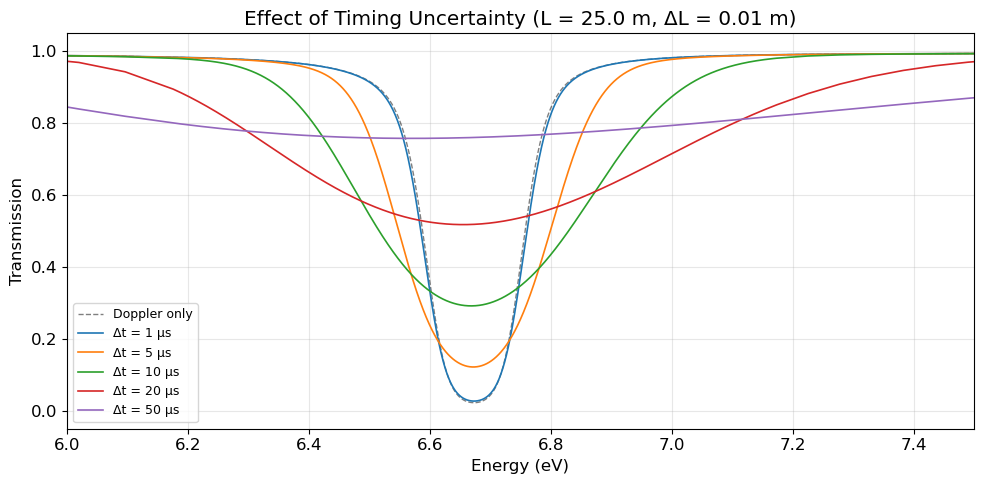

In [5]:
delta_t_values = [1.0, 5.0, 10.0, 20.0, 50.0]  # microseconds

fig, ax = plt.subplots(figsize=(10, 5))

# Baseline: Doppler only
T_doppler = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=300.0
))
ax.plot(energies, T_doppler, 'k--', alpha=0.5, label='Doppler only', linewidth=1)

for dt in delta_t_values:
    T = np.asarray(nereids.forward_model(
        energies, [(u238, thickness)], temperature_k=300.0,
        flight_path_m=flight_path, delta_t_us=dt, delta_l_m=delta_l
    ))
    ax.plot(energies, T, label=f'Δt = {dt:.0f} μs', linewidth=1.2)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title(f'Effect of Timing Uncertainty (L = {flight_path} m, ΔL = {delta_l} m)')
ax.legend(fontsize=9)
ax.set_xlim(6.0, 7.5)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Flight Path Scan

Longer flight paths improve energy resolution (larger TOF spread for given
timing uncertainty). VENUS has L ≈ 25 m; compare with shorter and longer paths.

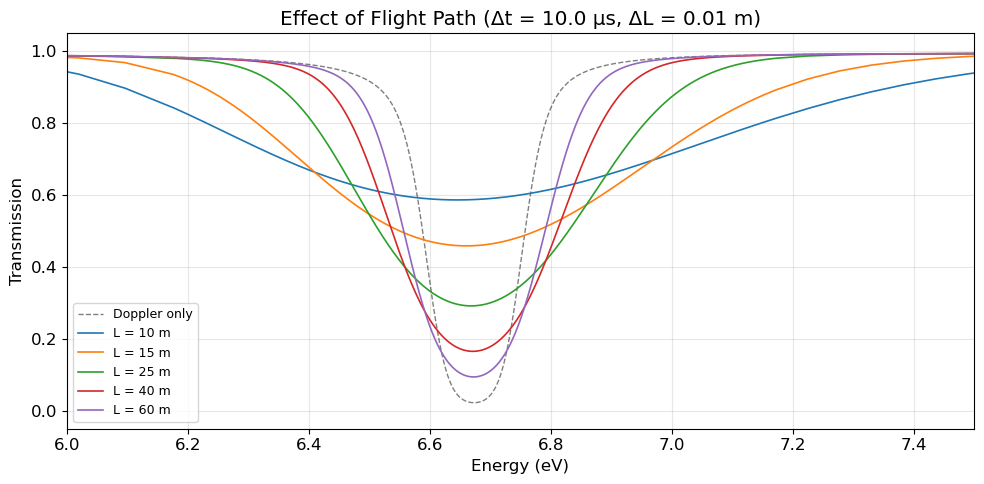

In [6]:
flight_paths = [10.0, 15.0, 25.0, 40.0, 60.0]  # meters

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(energies, T_doppler, 'k--', alpha=0.5, label='Doppler only', linewidth=1)

for L in flight_paths:
    T = np.asarray(nereids.forward_model(
        energies, [(u238, thickness)], temperature_k=300.0,
        flight_path_m=L, delta_t_us=delta_t, delta_l_m=delta_l
    ))
    ax.plot(energies, T, label=f'L = {L:.0f} m', linewidth=1.2)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title(f'Effect of Flight Path (Δt = {delta_t} μs, ΔL = {delta_l} m)')
ax.legend(fontsize=9)
ax.set_xlim(6.0, 7.5)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Resolution vs Doppler: Relative Contributions

For VENUS parameters, which broadening mechanism dominates at the U-238
6.674 eV resonance?

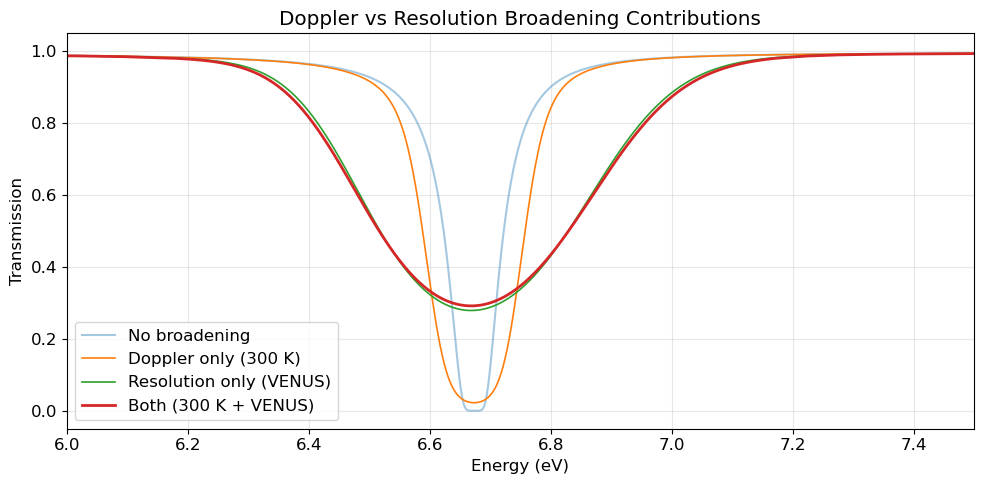

Transmission at 6.674 eV:
  No broadening:     0.0000
  Doppler only:      0.0224
  Resolution only:   0.2791
  Both:              0.2920


In [7]:
# Three cases: neither, Doppler only, resolution only, both
T_cold = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=0.0
))
T_doppler_only = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=300.0
))
T_resolution_only = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=0.0,
    flight_path_m=flight_path, delta_t_us=delta_t, delta_l_m=delta_l
))
T_both = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=300.0,
    flight_path_m=flight_path, delta_t_us=delta_t, delta_l_m=delta_l
))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(energies, T_cold, alpha=0.4, label='No broadening')
ax.plot(energies, T_doppler_only, label='Doppler only (300 K)', linewidth=1.2)
ax.plot(energies, T_resolution_only, label='Resolution only (VENUS)', linewidth=1.2)
ax.plot(energies, T_both, label='Both (300 K + VENUS)', linewidth=2)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Doppler vs Resolution Broadening Contributions')
ax.legend()
ax.set_xlim(6.0, 7.5)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify: dip depth at resonance
idx_res = np.argmin(np.abs(energies - 6.674))
print(f"Transmission at 6.674 eV:")
print(f"  No broadening:     {T_cold[idx_res]:.4f}")
print(f"  Doppler only:      {T_doppler_only[idx_res]:.4f}")
print(f"  Resolution only:   {T_resolution_only[idx_res]:.4f}")
print(f"  Both:              {T_both[idx_res]:.4f}")

## 7. Convolution Preserves Normalization

Resolution broadening is a convolution with a normalized kernel.
The integral of the transmission spectrum should be approximately preserved.

In [8]:
# Check that resolution broadening preserves integral
area_doppler = np.trapezoid(T_doppler_only, energies)
area_both = np.trapezoid(T_both, energies)
rel_change = abs(area_both - area_doppler) / area_doppler * 100

print(f"Integral (Doppler only): {area_doppler:.4f}")
print(f"Integral (both):         {area_both:.4f}")
print(f"Relative change:         {rel_change:.4f}%")

assert rel_change < 1.0, f"Resolution broadening changed integral by {rel_change:.2f}%"
print("Normalization preservation verified (< 1%)")

Integral (Doppler only): 29.1393
Integral (both):         29.0217
Relative change:         0.4035%
Normalization preservation verified (< 1%)


## 8. VENUS Parameters Summary

For reference, here are typical VENUS beamline parameters and their effect
on energy resolution at key resonance energies.

In [9]:
# VENUS parameters
L_venus = 25.0    # m
dt_venus = 10.0   # us (moderator + detector)
dl_venus = 0.01   # m (sample thickness contribution)

# Key isotope resonances for VENUS
resonances = [
    ('U-235', 8.78, 92, 235),
    ('U-238', 6.674, 92, 238),
    ('Pu-239', 0.296, 94, 239),
    ('Pu-241', 4.28, 94, 241),
    ('Fe-56', 1.15, 26, 56),
    ('Au-197', 4.906, 79, 197),
]

print(f"VENUS: L = {L_venus} m, Δt = {dt_venus} μs, ΔL = {dl_venus} m")
print()
print(f"{'Isotope':>10} {'E_r (eV)':>10} {'TOF (μs)':>10} {'ΔE/E (%)':>10} {'ΔE (meV)':>10}")
print("-" * 54)
for name, E_r, z, a in resonances:
    tof = nereids.energy_to_tof(E_r, L_venus)
    dE_over_E = np.sqrt((2*dt_venus/tof)**2 + (2*dl_venus/L_venus)**2)
    dE = dE_over_E * E_r * 1000  # meV
    print(f"{name:>10} {E_r:>10.3f} {tof:>10.1f} {dE_over_E*100:>10.3f} {dE:>10.2f}")

VENUS: L = 25.0 m, Δt = 10.0 μs, ΔL = 0.01 m

   Isotope   E_r (eV)   TOF (μs)   ΔE/E (%)   ΔE (meV)
------------------------------------------------------
     U-235      8.780      610.0      3.280     287.96
     U-238      6.674      699.6      2.860     190.86
    Pu-239      0.296     3322.2      0.607       1.80
    Pu-241      4.280      873.7      2.291      98.04
     Fe-56      1.150     1685.5      1.189      13.68
    Au-197      4.906      816.0      2.452     120.31


## Summary

| Property | Verified | Method |
|----------|----------|--------|
| Progressive broadening | Yes | Unbroadened → Doppler → Resolution |
| Energy-dependent width | Yes | ΔE/E computed at multiple energies |
| Timing uncertainty effect | Yes | Δt scan (1–50 μs) |
| Flight path effect | Yes | L scan (10–60 m) |
| Relative contributions | Yes | Doppler vs resolution at U-238 6.674 eV |
| Normalization preservation | Yes | Integral conserved to < 1% |

**Key findings**:
1. For VENUS (L=25 m, Δt=10 μs), resolution broadening is the dominant
   broadening mechanism at the U-238 6.674 eV resonance in this setup.
   The computed resolution scale (ΔE ≈ 0.19 eV) is much larger than the
   intrinsic resonance width (Γ ≈ 0.0245 eV), so instrument smearing strongly
   controls the observed dip depth.
2. Energy resolution ΔE/E improves at lower energies (longer TOF).
3. Longer flight paths improve resolution at fixed Δt.

**SAMMY reference**: `rsl/mrsl*.f90` (resolution functions), `grp/mgrp4.f90` (Lagrange quadrature).

For tabulated (non-Gaussian) resolution functions, see the
[Custom Resolution](../building_blocks/05_custom_resolution.ipynb) notebook.

**Previous:** [Doppler Broadening](03_doppler_broadening.ipynb)
**Next:** [URR Cross-Sections](05_urr_cross_sections.ipynb)
